In [10]:
pip install scikit-learn

     ---------------------------------------- 8.1/8.1 MB 9.2 MB/s eta 0:00:00
     ---------------------------------------- 36.6/36.6 MB 9.8 MB/s eta 0:00:00
     ------------------------------------- 309.1/309.1 kB 19.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Fitting and Alignment

1 a).

Slope: 1.2207
Intercept: -5.9872



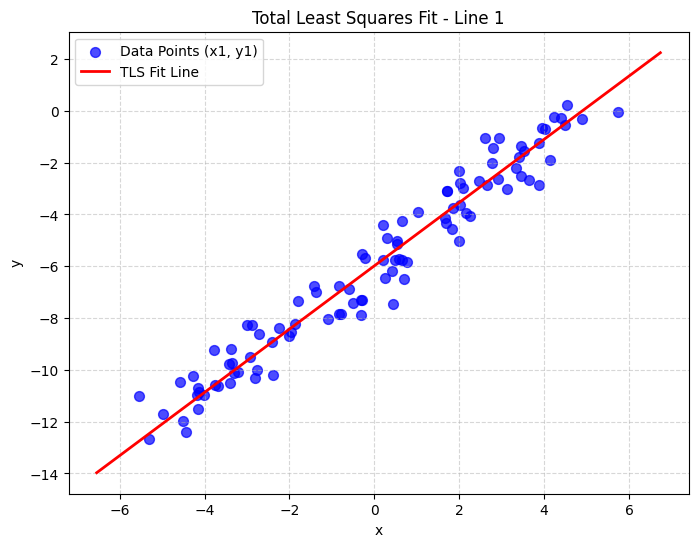

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the data (Adjust path as necessary)
try:
    D = np.genfromtxt("data/lines.csv", delimiter=",", skip_header=1)
except FileNotFoundError:
    print("\lines.csv not found. Using sample points from Table 1.")

# Extract data for the first line (x1 and y1)
x1 = D[:, 0]
y1 = D[:, 3]

def total_least_squares(x, y):
    # Center the data - critical for SVD
    x_mean, y_mean = np.mean(x), np.mean(y)
    x_centered, y_centered = x - x_mean, y - y_mean
    
    # Construct the matrix and solve via SVD
    A = np.vstack([x_centered, y_centered]).T
    _, _, Vh = np.linalg.svd(A)
    
    # The normal vector (a, b) is the last row of Vh
    a, b = Vh[-1, :]
    
    # Convert to y = mx + c
    slope = -a / b
    intercept = y_mean - slope * x_mean
    return slope, intercept

# Compute Parameters
m1, c1 = total_least_squares(x1, y1)
print(f"Slope: {m1:.4f}\nIntercept: {c1:.4f}\n")

plt.figure(figsize=(8, 6))
plt.scatter(x1, y1, color='blue', label='Data Points (x1, y1)', s=50, alpha=0.7)

# Generate the fitted line
x_vals = np.linspace(np.min(x1) - 1, np.max(x1) + 1, 100)
y_vals = m1 * x_vals + c1
plt.plot(x_vals, y_vals, color='red', linewidth=2, label=f'TLS Fit Line')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Total Least Squares Fit - Line 1')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

b).

Line 1: Slope = -0.5160, Intercept = 2.0079
Line 2: Slope = 1.0124, Intercept = 0.9305
Line 3: Slope = 1.2443, Intercept = -5.9312


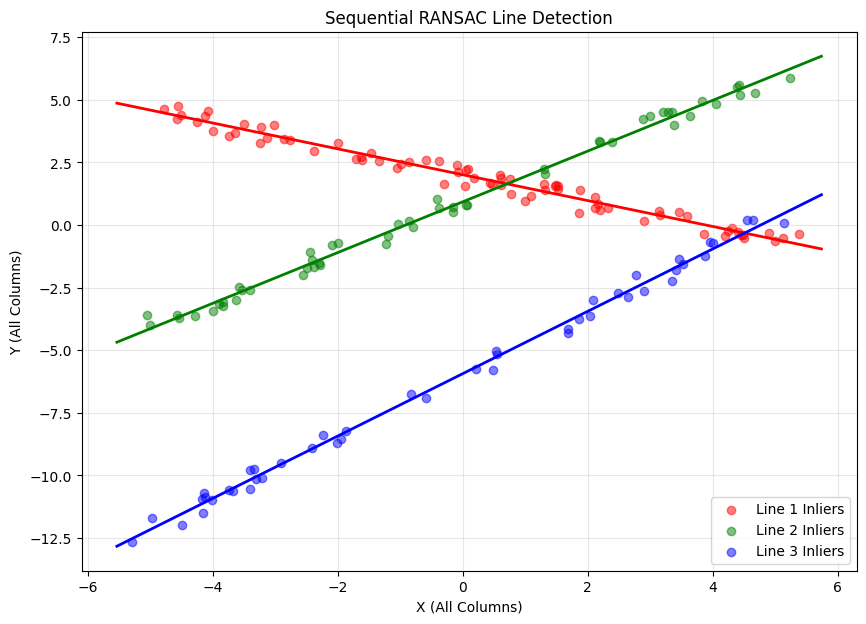

In [ ]:
from sklearn.linear_model import RANSACRegressor


X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten().reshape(-1, 1) 
Y_all = Y_cols.flatten()

# Storage for remaining data during iterative removal
current_X, current_Y = X_all.copy(), Y_all.copy()
colors = ['r', 'g', 'b']
plt.figure(figsize=(10, 7))


for i in range(3):
    # Fit RANSAC
    ransac = RANSACRegressor(residual_threshold=0.5)
    ransac.fit(current_X, current_Y)
    
    # Get parameters
    m = ransac.estimator_.coef_[0]
    b = ransac.estimator_.intercept_
    print(f"Line {i+1}: Slope = {m:.4f}, Intercept = {b:.4f}")
    
    # Identify and plot inliers
    inlier_mask = ransac.inlier_mask_
    plt.scatter(current_X[inlier_mask], current_Y[inlier_mask], color=colors[i], label=f'Line {i+1} Inliers', alpha=0.5)
    
    # Plot the line
    line_x = np.array([np.min(X_all), np.max(X_all)]).reshape(-1, 1)
    line_y = ransac.predict(line_x)
    plt.plot(line_x, line_y, color=colors[i], linewidth=2)
    
    # Mask the consensus and continue with outliers
    outlier_mask = np.logical_not(inlier_mask)
    current_X = current_X[outlier_mask]
    current_Y = current_Y[outlier_mask]

plt.title("Sequential RANSAC Line Detection")
plt.xlabel("X (All Columns)")
plt.ylabel("Y (All Columns)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

2.

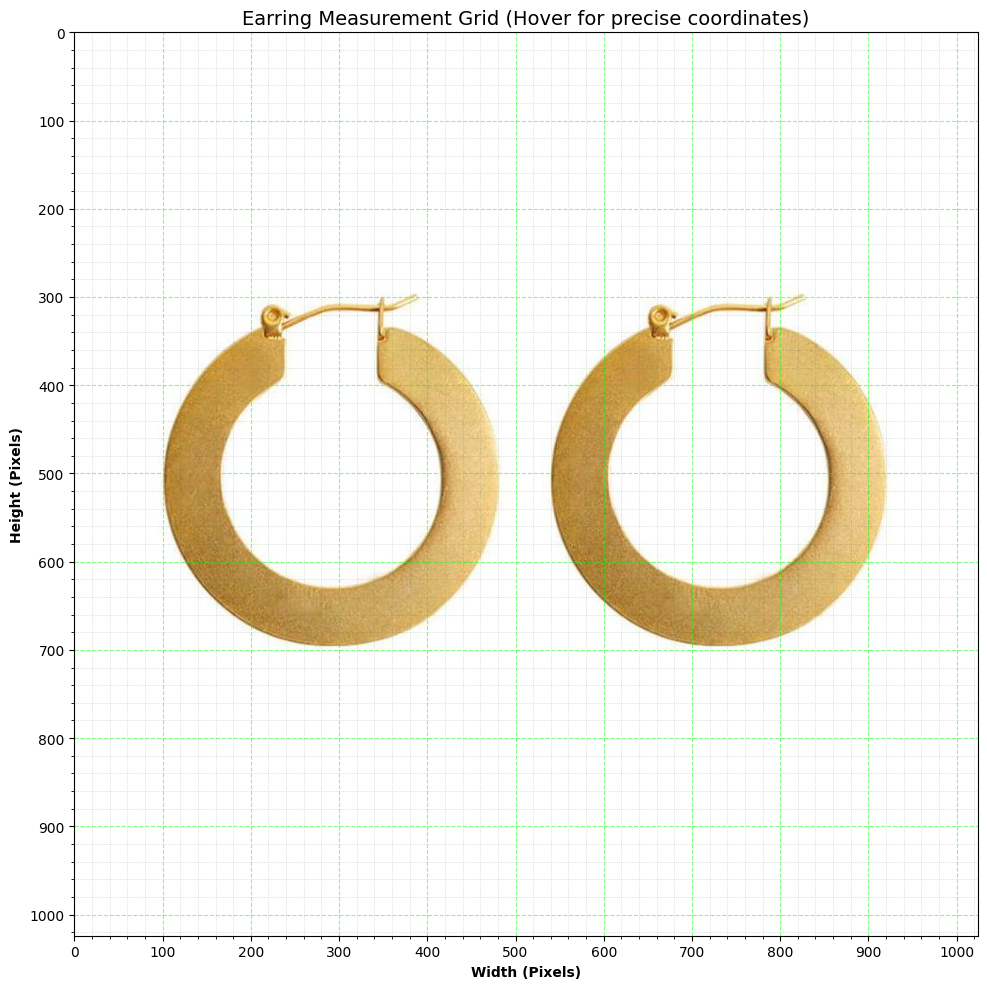

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load the image
img_earrings = cv2.imread("data/earrings.jpg")
if img_earrings is None:
    raise FileNotFoundError("Could not find earrings.jpg")

# Convert BGR to RGB
img_rgb = cv2.cvtColor(img_earrings, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img_rgb)
ax.set_title("Earring Measurement Grid (Hover for precise coordinates)", fontsize=14)

ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
ax.yaxis.set_major_locator(ticker.MultipleLocator(100))

ax.xaxis.set_minor_locator(ticker.MultipleLocator(20))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(20))


ax.grid(which='major', color='#00FF00', linestyle='--', alpha=0.5, linewidth=0.8)
ax.grid(which='minor', color="#435E43", linestyle=':', alpha=0.3, linewidth=0.5)

ax.set_xlabel("Width (Pixels)", fontweight='bold')
ax.set_ylabel("Height (Pixels)", fontweight='bold')
ax.set_xlim(0, w)
ax.set_ylim(h, 0)

plt.tight_layout()
plt.show()

3.

In [11]:
import cv2
import numpy as np

points = []
def mouse_callback(event, x, y, flags, param):
    global points, img_display
    if event == cv2.EVENT_LBUTTONDOWN:
        if len(points) < 4:
            points.append((x, y))
        
            print(f"Point {len(points)}: ({x}, {y})")
            cv2.circle(img_display, (x, y), 5, (0, 0, 255), -1)
            cv2.imshow("Image", img_display)
            
            if len(points) == 4:
                print("\nFour points selected:")
                for i, p in enumerate(points):
                    print(f"P{i+1}: {p}")
                print("Press any key to process the flag.")

# Load the images
img = cv2.imread("data/turf.jpg")
flag = cv2.imread("data/flag.jpg")

if img is None or flag is None:
    raise FileNotFoundError("Make sure both 'turf.jpg' and 'flag.jpg' are in the folder.")

img_display = img.copy()
cv2.namedWindow("Image")
cv2.setMouseCallback("Image", mouse_callback)
cv2.imshow("Image", img_display)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Convert list to numpy array as per your snippet
points = np.array(points, dtype=np.float32)


Point 1: (686, 164)
Point 2: (840, 161)
Point 3: (1379, 678)
Point 4: (97, 665)

Four points selected:
P1: (686, 164)
P2: (840, 161)
P3: (1379, 678)
P4: (97, 665)
Press any key to process the flag.


In [12]:

if len(points) == 4:
    # Define the dimensions of the flag
    h_f, w_f = flag.shape[:2]

    # Define the source coordinates 
    src_pts = np.array([
        [0, 0],
        [w_f - 1, 0],
        [w_f - 1, h_f - 1],
        [0, h_f - 1]
    ], dtype=np.float32)

    # Calculate the Perspective Transformation Matrix
    matrix = cv2.getPerspectiveTransform(src_pts, points)

    # Warp the flag to the perspective of the turf
    warped_flag = cv2.warpPerspective(flag, matrix, (img.shape[1], img.shape[0]))

    # Create a mask to cut a hole in the turf image
    mask = np.zeros_like(img, dtype=np.uint8)
    cv2.fillConvexPoly(mask, points.astype(int), (255, 255, 255))
    
    # Extract the background
    turf_background = cv2.bitwise_and(img, cv2.bitwise_not(mask))
    
    # Extract the foreground (the warped flag area only)
    flag_foreground = cv2.bitwise_and(warped_flag, mask)

    # Combine them
    final_result = cv2.add(turf_background, flag_foreground)

    # Display results
    cv2.imshow("Result", final_result)
    cv2.imwrite("data/superimposed_flag.jpg", final_result)
    print("\nSuccess! Result saved as 'superimposed_flag.jpg'")
    cv2.waitKey(0)
    cv2.destroyAllWindows()
else:
    print("Error: You didn't select exactly 4 points.")


Success! Result saved as 'superimposed_flag.jpg'
